### Dispersion Curves

In [1]:
import gc
import glob
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML
from tqdm import tqdm

sys.path.append('..')

from src.disp import dispersion_curve, extr_disp
from src.ncf import get_vs_number
from src.disp import regularize_dispersion_data, export_inversion_inputs
from src.plots import (plot_fv, plot_fv_pick, save_disp_picks,
                       animate_fv, animate_fv_pick, plot_scatter_section, plot_interpolated_section)

import matplotlib as mpl
mpl.rcParams["animation.html"] = "jshtml"
mpl.rcParams["animation.embed_limit"] = 500.0 

old_fig_dpi = plt.rcParams['figure.dpi']
old_save_dpi = plt.rcParams['savefig.dpi']

#### 1. Construct Dispersion Images

In [2]:
# Cable Configuration 
dx = 8.16

# Frequency-Velocity Panel Parameters
fv_kwargs = {
    "vmin": 100.0,
    "vmax": 1200.0,
    "dv": 1.0,       # 1 m/s resolution for precise mode picking
    "fmin": 0.5,     
    "fmax": 10.0,    # 10 Hz upper bound to track overtones
    "normalize": True,
    "device": torch.device("cpu") 
}

input_dir = "../data/ncf_disp_urban"
fv_out_dir = "../results/fv_panels_urban"
picks_out_dir = "../results/picks_urban"
os.makedirs(fv_out_dir, exist_ok=True)
os.makedirs(picks_out_dir, exist_ok=True)

In [ ]:
# Grab the newly split directional .npz files and sort them spatially
processed_files = sorted(glob.glob(f"{input_dir}/*.npz"), key=get_vs_number)
fv_results = {}

# Batch Compute f-v Panels
for fpath in tqdm(processed_files, desc="Computing & Saving f-v Panels"):
    
    # Load the pristine array data
    archive = np.load(fpath)
    data = archive["data"]
    offset = archive["offset"]
    lag = archive["lag"]
    side = str(archive["side"])
    
    # Convert all offsets to absolute distance. 
    # This ensures left-side (negative) traces scan positive velocities correctly.
    dist_abs = np.abs(offset)
    
    # Compute f-v panel (Phase-Shift Method)
    fv, f_axis, v_axis = dispersion_curve(
        data=data, 
        offset=dist_abs, 
        t=lag, 
        **fv_kwargs
    )
    
    fname = os.path.basename(fpath)
    save_name = fname.replace(".npz", "_fv.npz")
    save_path = os.path.join(fv_out_dir, save_name)
    
    # Move tensors to CPU/Numpy for storage compatibility
    fv_data_cpu = fv.cpu().numpy() if hasattr(fv, 'cpu') else fv
    f_axis_cpu = f_axis.cpu().numpy() if hasattr(f_axis, 'cpu') else f_axis
    v_axis_cpu = v_axis.cpu().numpy() if hasattr(v_axis, 'cpu') else v_axis
    
    np.savez_compressed(
        save_path,
        fv=fv_data_cpu,
        f_axis=f_axis_cpu,
        v_axis=v_axis_cpu,
        side=side
    )
    
    fv_results[fname] = {"fv": fv_data_cpu, "side": side}

print(f"Successfully saved {len(processed_files)} panels to {fv_out_dir}")

In [ ]:
fv_out_dir = "../results/fv_panels_urban"
all_saved_fv = sorted(glob.glob(f"{fv_out_dir}/*_fv.npz"))

right_side_files_s1_v1 = [
    f for f in all_saved_fv 
    if "_right" in f and "_s1" in f and "v1" in f
]

left_side_files_s1_v1 = [
    f for f in all_saved_fv 
    if "_left" in f and "_s1" in f and "v1" in f
]

fig, ax = plot_fv(
    fv_files=right_side_files_s1_v1 + left_side_files_s1_v1,
    VS=70,
    xmin=1.0,
    xmax=9.0,
    ymin=100.0,
    ymax=1200.0,
    cmap="viridis",
    figsize=(8, 6),
    title="Dispersion Spectrum (S1)",
    show_cbar=True,
    dpi=150
)

plt.show()

In [ ]:
try:
    plt.rcParams.update({
        'figure.dpi': 120,        
        'savefig.dpi': 120,
        'axes.titlesize': 14,
    })

    ani_smooth = animate_fv(
    fv_files=right_side_files_s1_v1+left_side_files_s1_v1, 
    xmin=1.0,    
    xmax=9.0,    
    ymin=100.0,   
    ymax=1200.0, 
    cmap="viridis",
    interval_ms=300, 
    figsize=(8, 6)
)
    
    output = HTML(ani_smooth.to_jshtml())

finally:
    plt.rcParams.update({
        'figure.dpi': old_fig_dpi,
        'savefig.dpi': old_save_dpi,
    })

display(output)

plt.close('all')
del ani_smooth, output
gc.collect()

#### 2. Picks

In [ ]:
# Load just one to pick
fv_files = sorted(glob.glob(os.path.join(fv_out_dir, "*_fv.npz")))

In [ ]:
# Define manual packing parameters
# High SNR, smaller step is safer
# Lower SNR, might need larger step (e.g., 5)
pick_configs = {
    # --- Right Side Group (S1) ---
    "20211012_cc_020_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 400, 400, 400, 400, 390], "f_mask": (1.5, 8.5), "step": 1},
    "20211012_cc_025_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 400, 400, 400, 390, 390], "f_mask": (1.5, 7.5), "step": 1},
    "20211012_cc_030_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [590, 400, 400, 400, 390, 390, 390], "f_mask": (1.5, 9.0), "step": 1},
    "20211012_cc_035_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [590, 400, 400, 400, 390, 390, 390], "f_mask": (1.5, 9.0), "step": 1},
    "20211012_cc_040_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [550, 400, 400, 400, 320, 380, 380], "f_mask": (1.5, 8.0), "step": 1},
    "20211012_cc_045_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [550, 400, 400, 400, 390, 310], "f_mask": (1.5, 6.5), "step": 1},
    "20211012_cc_050_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [600, 450, 400, 390, 390, 390, 390], "f_mask": (1.5, 8.5), "step": 1},
    "20211012_cc_055_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [600, 450, 400, 390, 380, 320, 320], "f_mask": (1.5, 8.5), "step": 1},
    "20211012_cc_060_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [600, 450, 400, 390, 380, 380, 380], "f_mask": (1.5, 7.5), "step": 1},
    "20211012_cc_065_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [600, 450, 400, 390, 390, 390, 390], "f_mask": (1.5, 9.0), "step": 1},
    "20211012_cc_070_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [600, 450, 400, 390, 390, 390, 390], "f_mask": (1.5, 9.0), "step": 1},
    "20211012_cc_075_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0, 7.0, 8.0], "vmax_set": [600, 450, 400, 390, 390, 390, 390], "f_mask": (1.5, 8.5), "step": 1},
    "20211012_cc_080_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [1.5, 2.0, 4.0, 5.0, 6.0], "vmax_set": [600, 450, 450, 390, 390], "f_mask": (1.5, 6.5), "step": 1},
    "20211012_cc_085_45d_v1_s1_fk_100_2000_right": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0], "vmax_set": [600, 500, 500, 390, 390], "f_mask": (2.5, 8.5), "step": 1},

    # # # --- Left Side Group (S1) ---
    "20211012_cc_065_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (2.0, 9.0), "step": 1},
    "20211012_cc_070_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (1.5, 7.5), "step": 1},
    "20211012_cc_075_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (2.0, 7.0), "step": 1},
    "20211012_cc_080_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (2.0, 6.5), "step": 1},
    "20211012_cc_085_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (1.9, 7.0), "step": 1},
    "20211012_cc_090_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 330, 370], "f_mask": (1.9, 8.5), "step": 1},
    "20211012_cc_095_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (2.0, 7.0), "step": 1},
    "20211012_cc_100_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (1.9, 7.0), "step": 1},
    "20211012_cc_105_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 320, 320], "f_mask": (1.9, 9.0), "step": 1},
    "20211012_cc_110_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (1.9, 8.0), "step": 1},
    "20211012_cc_120_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (1.9, 7.0), "step": 1},
    "20211012_cc_125_45d_v1_s1_fk_100_2000_left": {"f_ref_set": [2.0, 3.0, 4.0, 5.0, 6.0, 7.0], "vmax_set": [600, 500, 500, 390, 370, 370], "f_mask": (1.9, 9.0), "step": 1},
}

In [ ]:
# Run picking 
for fpath in tqdm(fv_files, desc="Picking Dispersion Curves"):
    fname_full = os.path.basename(fpath)
    
    # Identify which config to use
    matched_config = None
    for key in pick_configs:
        if key in fname_full:
            matched_config = pick_configs[key]
            break
            
    if not matched_config:
        continue
        
    # Load the f-v panel and axes
    data = np.load(fpath, allow_pickle=True) 
    
    # Get individual parameters
    f_ref = matched_config["f_ref_set"]
    v_max_ref = matched_config["vmax_set"]
    f_min, f_max = matched_config["f_mask"]
    individual_step = matched_config.get("step", 3) 
    
    # Velocity Mute
    vmin_threshold = matched_config.get("vmin", 250) # Fallback to 250 m/s
    fv_panel_cleaned = data["fv"].copy()
    v_axis = data["v_axis"]
    
    # Find which indices are below our threshold
    low_v_mask = v_axis < vmin_threshold
    
    # Zero out the amplitudes in the fv matrix below the vmin threshold.
    # We check the shape to ensure we mute the correct axis.
    if fv_panel_cleaned.shape[0] == len(v_axis):
        fv_panel_cleaned[low_v_mask, :] = 0  # v is the rows
    else:
        fv_panel_cleaned[:, low_v_mask] = 0  # v is the columns
    
    try:
        # Run ridge tracking algorithm on the CLEANED panel
        raw_v_picks = extr_disp(
            data["f_axis"], 
            data["v_axis"], 
            fv_panel_cleaned, # <--- Pass the muted panel here
            f_ref_set=f_ref, 
            vmax_set=v_max_ref, 
            step=individual_step
        )
        
        # Apply the frequency mask to keep only reliable data
        f_axis = data["f_axis"]
        mask = (f_axis >= f_min) & (f_axis <= f_max)
        
        # Build the result dictionary
        pick_result = {
            "f": f_axis[mask],
            "v": raw_v_picks[mask],
            "vs_m": data.get("vs_m"),
            "side": data.get("side"),
            "params": matched_config,
            "original_fv_file": fname_full
        }
        
        # Save to ../results/picks/
        out_name = fname_full.replace("_fv.npz", "_pick.npy")
        np.save(os.path.join(picks_out_dir, out_name), pick_result)
        
    except Exception as e:
        print(f"\n[Error] Failed to pick {fname_full}: {e}")

print(f"\nProcessing complete. Picks saved to: {os.path.abspath(picks_out_dir)}")

In [ ]:
# 1. Filter the global list to ONLY include files defined in your pick_configs
files_to_animate = [
    fpath for fpath in fv_files 
    if any(key in os.path.basename(fpath) for key in pick_configs.keys())
]

print(f"Found {len(files_to_animate)} configured files to animate.")

In [ ]:
ani_inspect = animate_fv_pick(
        fv_files=files_to_animate, 
        picks_dir=picks_out_dir,                                 
        xmin=1.0,
        xmax=9.0,
        ymin=100.0,
        ymax=1200.0,
        cmap="magma",       
        interval_ms=500,                                          
        figsize=(10, 6)
    )

output = HTML(ani_inspect.to_jshtml())
display(output)

del ani_inspect, output
gc.collect()

In [ ]:
picks_fig_dir = "../results/picks_figs_urban"
save_disp_picks(
    fv_files=files_to_animate,
    picks_dir=picks_out_dir,
    outdir=picks_fig_dir,
 
    cmap="viridis",  
    fmt="png",
    dpi=300
)

In [ ]:
fig, ax = plot_fv_pick(
    fv_files=right_side_files_s1_v1 + left_side_files_s1_v1,
    VS=70,
    picks_dir=picks_out_dir,
    xmin=1.0,
    xmax=9.0,
    ymin=100.0,
    ymax=1200.0,
    cmap="magma",
    figsize=(10, 6),
    title="Dispersion Spectrum (S1) + Picks",
    show_cbar=True,
    dpi=150
)

plt.show()

#### 3. Mapping Picks

In [3]:
pick_files = sorted(glob.glob(os.path.join(picks_out_dir, "*_pick.npy")))

# List to hold our scatter plot data
x_dist = []
y_freq = []
z_vel = []
markers = [] # to distinguish S1 (right) and S2 (left)

for fpath in pick_files:
    fname = os.path.basename(fpath)

    # Extract the virtual shot index from the filename
    # Assuming standard format: '20210928_cc_020_30d_v1_s1_right_pick.npy'
    parts = fname.split('_')
    try:
        vs_idx = int(parts[2])  # '020' -> 20
    except ValueError:
        print(f"Skipping {fname}: could not parse VS index.")
        continue

    # Calculate the distance from the virtual source (VS)
    distance_m = vs_idx * dx

    # Load the picked data
    data = np.load(fpath, allow_pickle=True).item()
    f = data["f"]          # Frequency axis
    v = data["v"]          # Picked phase velocities

    # Determine side for marker styling
    is_s1 = "s1" in fname.lower()

    # Append to our master lists
    x_dist.extend([distance_m] * len(f))
    y_freq.extend(f)
    z_vel.extend(v)
    markers.extend(['o' if is_s1 else 's'] * len(f)) # 'o' for S1, square for S2

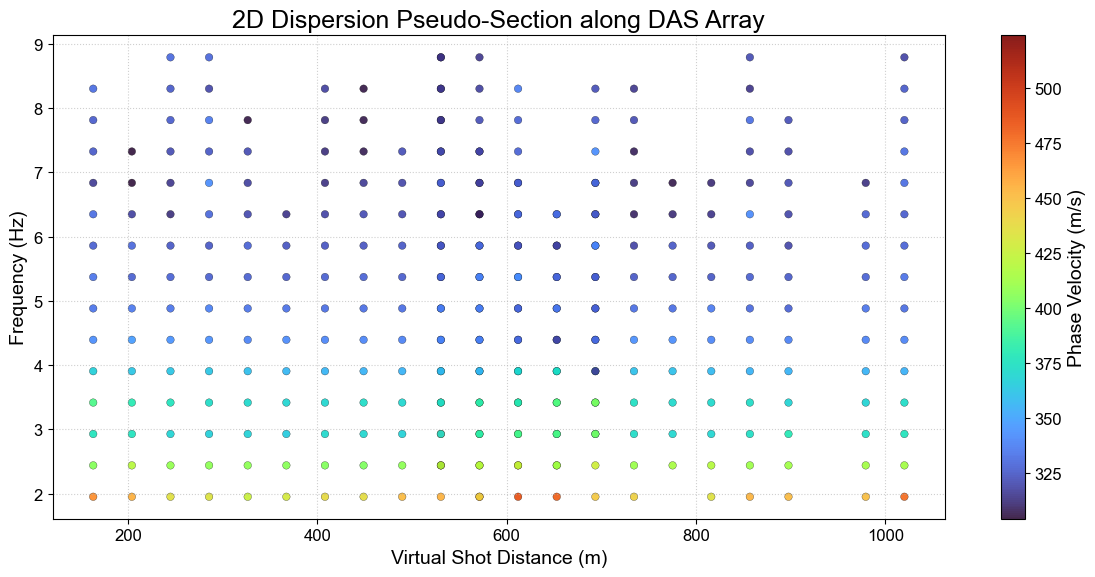

In [4]:
plot_scatter_section(x_dist, y_freq, z_vel, title="2D Dispersion Pseudo-Section along DAS Array")

In [5]:
x_reg, y_reg, z_reg, regularized_profiles = regularize_dispersion_data(x_dist, y_freq, z_vel, f_min=2.0, f_max=9.0, f_step=0.5)

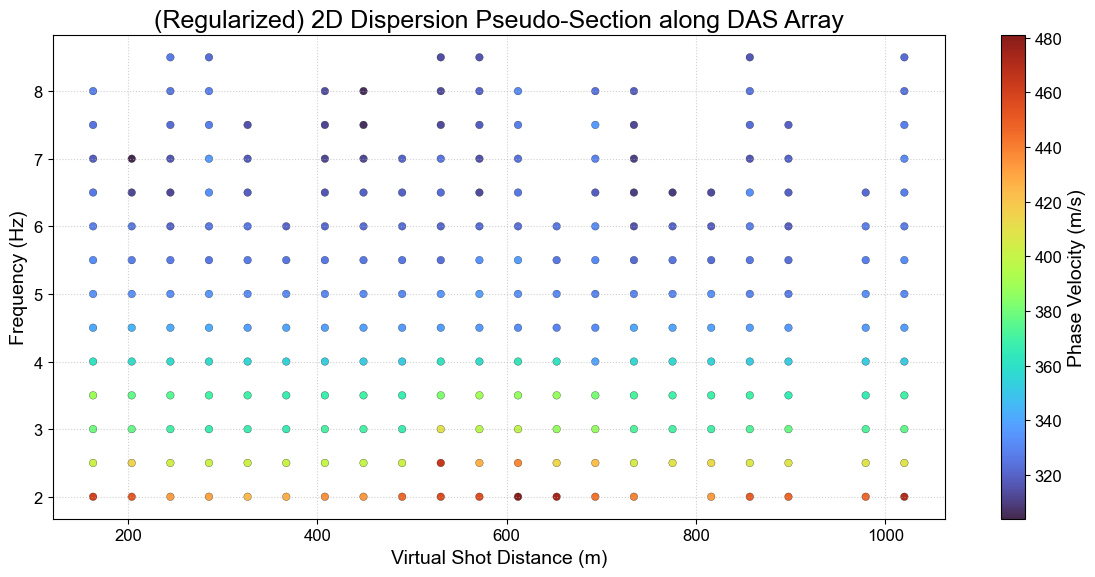

In [6]:
plot_scatter_section(x_reg, y_reg, z_reg, title="(Regularized) 2D Dispersion Pseudo-Section along DAS Array")

In [7]:
export_inversion_inputs(regularized_profiles, output_dir="../results/inv_inputs_urban")